In [90]:
import random
import time
import matplotlib.pyplot as plt
import numpy as np

In [91]:
def bubble_sort(arr):
    n = len(arr)
    comparisons = 0
    swaps = 0
    arr_copy = arr.copy()
    
    for i in range(n - 1):
        for j in range(n - i - 1):
            comparisons += 1
            if arr_copy[j] > arr_copy[j + 1]:
                arr_copy[j], arr_copy[j + 1] = arr_copy[j + 1], arr_copy[j]
                swaps += 1
    
    return arr_copy, comparisons, swaps

In [92]:
def gnome_sort(arr):
    n = len(arr)
    comparisons = 0
    swaps = 0
    arr_copy = arr.copy()
    
    index = 0
    while index < n:
        if index == 0:
            index += 1
        comparisons += 1
        if arr_copy[index] >= arr_copy[index - 1]:
            index += 1
        else:
            arr_copy[index], arr_copy[index - 1] = arr_copy[index - 1], arr_copy[index]
            swaps += 1
            index -= 1
    
    return arr_copy, comparisons, swaps

In [93]:
def insertion_sort(arr):
    n = len(arr)
    comparisons = 0
    swaps = 0
    arr_copy = arr.copy()
    
    for i in range(1, n):
        key = arr_copy[i]
        j = i - 1
        while j >= 0 and arr_copy[j] > key:
            comparisons += 1
            arr_copy[j + 1] = arr_copy[j]
            swaps += 1
            j -= 1
        if j >= 0:
            comparisons += 1
        arr_copy[j + 1] = key
        if j + 1 != i:
            swaps += 1
    
    return arr_copy, comparisons, swaps

In [94]:
def measure_sort_time(sort_func, arr):
    start_time = time.perf_counter()
    sorted_arr, comparisons, swaps = sort_func(arr)
    end_time = time.perf_counter()
    
    execution_time = (end_time - start_time) * 1000
    return execution_time, comparisons, swaps

In [95]:
def generate_random_array(size, min_val=1, max_val=1000):
    return [random.randint(min_val, max_val) for _ in range(size)]

In [96]:
def measure_sort_time(sort_func, arr):
    start_time = time.perf_counter()
    sorted_arr, comparisons, swaps = sort_func(arr)
    end_time = time.perf_counter()
    
    execution_time = (end_time - start_time) * 1000
    return execution_time, comparisons, swaps

In [97]:
def generate_random_array(size, min_val, max_val):
    return [random.randint(min_val, max_val) for _ in range(size)]

In [98]:
sizes = [10, 50, 100, 200, 500, 1000, 2000, 3000, 4000, 5000]

MIN_VALUE = 1
MAX_VALUE = 10000

bubble_times = []
gnome_times = []
insertion_times = []

bubble_comparisons = []
gnome_comparisons = []
insertion_comparisons = []

bubble_swaps = []
gnome_swaps = []
insertion_swaps = []

In [99]:
print("=" * 100)
print(f"{'Размер':^10} | {'Пузырек (мс)':^15} | {'Гномья (мс)':^15} | {'Вставки (мс)':^15} | {'Сравнения (П/Г/В)':^35}")
print("=" * 100)

for size in sizes:
    arr = generate_random_array(size, MIN_VALUE, MAX_VALUE)
    
    bubble_time, bubble_comp, bubble_swap = measure_sort_time(bubble_sort, arr)
    bubble_times.append(bubble_time)
    bubble_comparisons.append(bubble_comp)
    bubble_swaps.append(bubble_swap)
    
    gnome_time, gnome_comp, gnome_swap = measure_sort_time(gnome_sort, arr)
    gnome_times.append(gnome_time)
    gnome_comparisons.append(gnome_comp)
    gnome_swaps.append(gnome_swap)
    
    insertion_time, insertion_comp, insertion_swap = measure_sort_time(insertion_sort, arr)
    insertion_times.append(insertion_time)
    insertion_comparisons.append(insertion_comp)
    insertion_swaps.append(insertion_swap)
    
    print(f"{size:^10} | {bubble_time:^15.3f} | {gnome_time:^15.3f} | {insertion_time:^15.3f} | "
          f"{bubble_comp:^10}|{gnome_comp:^10}|{insertion_comp:^10}")

print("=" * 100)

  Размер   |  Пузырек (мс)   |   Гномья (мс)   |  Вставки (мс)   |          Сравнения (П/Г/В)         
    10     |      0.009      |      0.005      |      0.004      |     45    |    40    |    24    
    50     |      0.082      |      0.097      |      0.044      |    1225   |   1380   |   713    
   100     |      0.293      |      0.459      |      0.182      |    4950   |   5014   |   2554   
   200     |      1.222      |      4.612      |      0.661      |   19900   |  20136   |  10164   
   500     |      8.870      |     11.149      |      4.582      |   124750  |  129459  |  64975   
   1000    |     38.984      |     40.550      |     18.202      |   499500  |  503200  |  252097  
   2000    |     147.544     |     169.679     |     69.782      |  1999000  | 1984071  |  993030  
   3000    |     331.611     |     370.528     |     166.417     |  4498500  | 4404874  | 2203932  
   4000    |     611.456     |     671.375     |     281.141     |  7998000  | 7991318  | 3997654

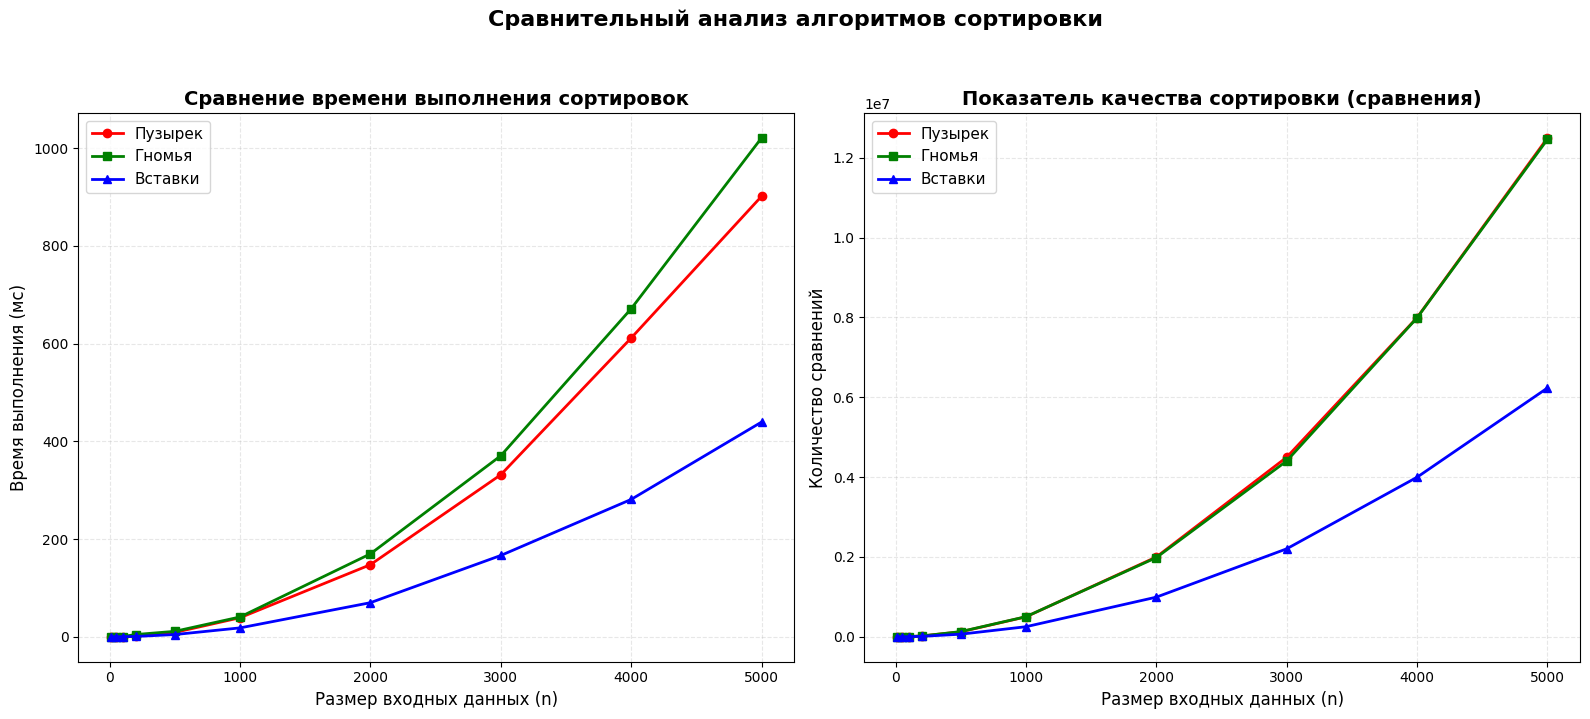

In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.plot(sizes, bubble_times, 'ro-', linewidth=2, markersize=6, label='Пузырек')
ax1.plot(sizes, gnome_times, 'gs-', linewidth=2, markersize=6, label='Гномья')
ax1.plot(sizes, insertion_times, 'b^-', linewidth=2, markersize=6, label='Вставки')

ax1.set_xlabel('Размер входных данных (n)', fontsize=12)
ax1.set_ylabel('Время выполнения (мс)', fontsize=12)
ax1.set_title('Сравнение времени выполнения сортировок', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)


ax2.plot(sizes, bubble_comparisons, 'ro-', linewidth=2, markersize=6, label='Пузырек')
ax2.plot(sizes, gnome_comparisons, 'gs-', linewidth=2, markersize=6, label='Гномья')
ax2.plot(sizes, insertion_comparisons, 'b^-', linewidth=2, markersize=6, label='Вставки')

ax2.set_xlabel('Размер входных данных (n)', fontsize=12)
ax2.set_ylabel('Количество сравнений', fontsize=12)
ax2.set_title('Показатель качества сортировки (сравнения)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11)

plt.suptitle('Сравнительный анализ алгоритмов сортировки', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('sorting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [101]:
print(f"{'Алгоритм':<15} | {'Среднее время (мс)':<20} | {'Среднее сравнений':<20} | {'Среднее обменов':<20}")
print("-" * 100)
print(f"{'Пузырек':<15} | {np.mean(bubble_times):<20.3f} | {np.mean(bubble_comparisons):<20.0f} | {np.mean(bubble_swaps):<20.0f}")
print(f"{'Гномья':<15} | {np.mean(gnome_times):<20.3f} | {np.mean(gnome_comparisons):<20.0f} | {np.mean(gnome_swaps):<20.0f}")
print(f"{'Вставки':<15} | {np.mean(insertion_times):<20.3f} | {np.mean(insertion_comparisons):<20.0f} | {np.mean(insertion_swaps):<20.0f}")

Алгоритм        | Среднее время (мс)   | Среднее сравнений    | Среднее обменов     
----------------------------------------------------------------------------------------------------
Пузырек         | 204.157              | 2764337              | 1374287             
Гномья          | 228.943              | 2750153              | 1374287             
Вставки         | 98.047               | 1375866              | 1375867             
